# Spatial Analysis of Agricultural Vulnerability and Flood Exposure
**Project:** Climate-Driven Vulnerability of Boro Rice Yield Across Bangladesh's 64 Districts (2001–2022)  
**Author:** Tasnim Ahmad Mumu  
**Last updated:** 2026

---

## Abstract

This notebook conducts the spatial analysis component of the research project. It integrates static structural flood risk data (BARC hazard zones) with dynamic annual flood inundation fractions derived from the JRC Global Surface Water dataset, overlays both onto Bangladesh's 64 administrative districts, and applies spatial autocorrelation methods to test whether the district-level agricultural vulnerability index exhibits geographic clustering. The primary finding — Global Moran's I = 0.804 (p < 0.001) — establishes that vulnerability is not randomly distributed but concentrated in a coherent southwest belt, motivating the spatially-stratified regression analysis in the companion statistical modelling notebook.

## Inputs

| Input | Source | Layer |
|---|---|---|
| `mart_vulnerability_index` | DuckDB Gold | Composite vulnerability scores for 64 districts |
| `fact_district_season` | DuckDB Gold | District × season × year panel (pre-flood extension) |
| GADM district shapefile | Bronze | 64-district polygon boundaries |
| BARC flood hazard shapefile | HDX | Static structural flood risk zones (FLOODCAT) |
| LGED river network | HDX | River line network for cartographic overlays |
| JRC surface water (GEE) | Google Earth Engine | Annual flood inundation fraction 2001–2021 |

## Outputs

| Output | Type | Description |
|---|---|---|
| `silver_flood_fraction.parquet` | Silver Parquet | Annual flood fraction + anomaly per district |
| `silver_district_flood_risk.parquet` | Silver Parquet | BARC static flood risk tier per district |
| `silver_spatial_analysis.parquet` | Silver Parquet | LISA cluster assignments and p-values |
| `map1_vulnerability_index.html` | Interactive map | Vulnerability index choropleth |
| `map2_flood_fraction.html` | Interactive map | Mean annual flood fraction choropleth |
| `map3_lisa_clusters.html` | Interactive map | LISA spatial cluster assignments |
| `fig1_vulnerability_flood_combined.png` | Publication figure | 300 DPI two-panel combined figure |
| `fact_district_season_v2` | DuckDB Gold | Fact table extended with flood variables |

## How to Run

Requires the pipeline notebook (`01_Data_Engineering_Pipeline.ipynb`) to have been executed first. The DuckDB database at `data/gold/bangladesh_agri.duckdb` must contain `mart_vulnerability_index` and `fact_district_season`.

Cell 1 (setup) must be run at the start of every session. All subsequent cells perform defensive reloads from disk and are safe to re-run in isolation after a kernel restart.

---
## 0. Environment Setup

All imports and shared helper functions for this notebook. The `load_districts()` function is the canonical entry point for the GADM shapefile — it handles both the raw GADM column names (`NAME_2`, `NAME_1`, `GID_2`) and the truncated names produced by QGIS shapefile export (`district_n`, `division_n`), ensuring consistent column names regardless of which shapefile version is present.

In [1]:
# ── Install packages (run once — comment out after first run) ──────────────
# !pip install geopandas libpysal esda folium branca duckdb pyarrow

# ── Standard library ──────────────────────────────────────────────────────
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Spatial statistics ────────────────────────────────────────────────────
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

# ── Interactive mapping ───────────────────────────────────────────────────
import folium
import branca.colormap as cm

# ── Analytical database ───────────────────────────────────────────────────
import duckdb

print("All imports OK")

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


All imports OK


### Shared Constants and Helper Functions

In [2]:
# ── Project paths ─────────────────────────────────────────────────────────
BRONZE = Path("data/bronze")
SILVER = Path("data/silver")
GOLD   = Path("data/gold")
GIS    = Path("data/gis")
MAPS   = Path("outputs/maps")

for p in [GIS, MAPS]:
    p.mkdir(parents=True, exist_ok=True)

# ── DuckDB connection ──────────────────────────────────────────────────────
DB_PATH = str(GOLD / "bangladesh_agri.duckdb")
con     = duckdb.connect(DB_PATH)

def q(sql):
    return con.execute(sql).df()

# ── Shapefile path — resolved once, reused everywhere ─────────────────────
# Checks for the clean shapefile produced by Phase 1e first;
# falls back to raw GADM download if the clean version is absent.
SHP_CANDIDATES = [
    BRONZE / "gadm_shapefiles/bangladesh_districts_clean.shp",
    BRONZE / "gadm_shapefiles/gadm41_BGD_2.shp",
]
SHP_PATH = next((p for p in SHP_CANDIDATES if p.exists()), None)
if SHP_PATH is None:
    raise FileNotFoundError("District shapefile not found — run Phase 1e first")

# ── HDX download helper ────────────────────────────────────────────────────
HDX_HEADERS = {"User-Agent": "Mozilla/5.0 (research)", "Accept": "*/*"}

def download_hdx(url, dest_path, label="file"):
    """Download from HDX following redirects. Skips if already cached."""
    dest = Path(dest_path)
    if dest.exists():
        print(f"  Cached: {dest.name}")
        return dest
    print(f"  Downloading {label}...")
    r = requests.get(url, headers=HDX_HEADERS,
                     allow_redirects=True, timeout=120, stream=True)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(chunk_size=65536):
            f.write(chunk)
    print(f"  Saved → {dest.name} ({dest.stat().st_size//1024} KB)")
    return dest

# ── District loader ────────────────────────────────────────────────────────
# The .shp format truncates column names to 10 characters.
# This function always renames them to full names before returning,
# and performs a fallback keyword search if a standard name is missing.

def find_col(df, keywords):
    """Return the first column whose name contains any keyword (case-insensitive)."""
    for kw in keywords:
        match = next((c for c in df.columns if kw in c.lower()), None)
        if match:
            return match
    return None

def load_districts(crs="EPSG:4326"):
    """
    Load the Bangladesh 64-district GeoDataFrame with fully standardised column names.
    Works with both the clean shapefile (district_n, division_n) and raw GADM
    (NAME_2, NAME_1). Safe to call multiple times — idempotent.
    """
    gdf = gpd.read_file(SHP_PATH)

    # Rename known truncated and GADM column names to full names
    col_map = {
        "district_n": "district_name",
        "division_n": "division_name",
        "district_c": "district_code",
        "NAME_2":     "district_name",
        "NAME_1":     "division_name",
        "GID_2":      "district_code",
    }
    gdf = gdf.rename(columns=col_map)

    # Fallback search for any column that was not caught by the rename above
    for target, keywords in [
        ("district_name", ["district_name", "district_n", "name_2", "distname", "district"]),
        ("division_name", ["division_name", "division_n", "name_1", "divname",  "division"]),
        ("district_code", ["district_code", "district_c", "gid_2",  "distcode"]),
    ]:
        if target not in gdf.columns:
            found = find_col(gdf, keywords)
            if found:
                gdf = gdf.rename(columns={found: target})
            else:
                print(f"WARNING: '{target}' not found. Columns: {gdf.columns.tolist()}")

    return gdf.to_crs(crs)

# ── Verify Gold layer is ready ─────────────────────────────────────────────
tables = q("SHOW TABLES")["name"].tolist()
print(f"DuckDB tables: {tables}")
if "mart_vulnerability_index" not in tables:
    raise RuntimeError("mart_vulnerability_index not found — run Phase 3 first")
print("Ready for Phase 4")

DuckDB tables: ['fact_district_season', 'fact_district_season_v2', 'mart_vulnerability_index', 'stg_boro_panel', 'stg_climate', 'stg_dim_district', 'stg_fao_national', 'stg_flood', 'stg_flood_risk', 'stg_ndvi']
Ready for Phase 4


---
## Section 1. GIS Data Acquisition

Two shapefiles are downloaded from the Humanitarian Data Exchange (HDX):

**BARC Flood Hazard Zones** (Bangladesh Agricultural Research Council)  
Dataset ID: `7362ef2d-7282-459f-bc1b-0347076fcc12`  
The FLOODCAT field classifies land parcels by structural flood risk derived from long-term hydrological modelling:

| FLOODCAT | Label | Three-tier classification |
|---|---|---|
| 0 | Not flood prone | Low |
| 2 | Moderately flood prone | Medium |
| 3 | Severely flood prone (river) | High |
| 5 | Very severely flood prone | High |
| 6 | Extremely flood prone | High |
| 7 | Coastal tidal flooding | Medium |
| 8 | Moderate tidal surge | Medium |

**LGED River Network** (Local Government Engineering Department)  
Used as a contextual overlay on all maps to illustrate the spatial relationship between river corridors and flood-prone districts.

Both downloads are cached locally — re-running this cell after the first download is safe and fast.

In [3]:
# ── 1. BARC Flood Risk Shapefile ───────────────────────────────────────────
# Source:  Bangladesh Hazards dataset (OCHA / BARC)
# FLOODCAT values: 0=not prone, 2=moderate, 3=severe river flooding,
#                  5=very severe, 6=extreme, 7=coastal tidal, 8=moderate tidal

flood_zip = download_hdx(
    "https://data.humdata.org/dataset/7362ef2d-7282-459f-bc1b-0347076fcc12"
    "/resource/ca979980-e533-43f8-83c9-2a6b5ac570c6"
    "/download/bgd_nhr_floods_barc.zip",
    GIS / "bgd_nhr_floods_barc.zip",
    "BARC flood risk shapefile",
)

flood_dir = GIS / "flood_risk_barc"
flood_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(flood_zip, "r") as z:
    z.extractall(flood_dir)

# BARC ZIP nests files inside a subfolder — glob recursively
flood_shp = list(flood_dir.glob("**/*.shp"))
if not flood_shp:
    raise FileNotFoundError(f"No .shp found in {flood_dir}")

gdf_flood_risk = gpd.read_file(flood_shp[0])
print(f"Flood risk: {len(gdf_flood_risk)} features | CRS: {gdf_flood_risk.crs}")
print(f"Columns: {gdf_flood_risk.columns.tolist()}")
print(f"FLOODCAT values: {sorted(gdf_flood_risk['FLOODCAT'].unique())}")


# ── 2. LGED Rivers Shapefile ───────────────────────────────────────────────
rivers_zip = download_hdx(
    "https://data.humdata.org/dataset/bangladesh-water-courses"
    "/resource/7f834bdb-b8f7-4f74-bf16-879fb7b72fc2"
    "/download/bgd_hyd_rivers_lged.zip",
    GIS / "bgd_hyd_rivers_lged.zip",
    "LGED rivers shapefile",
)

rivers_dir = GIS / "rivers"
rivers_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(rivers_zip, "r") as z:
    z.extractall(rivers_dir)

gdf_rivers = gpd.read_file(list(rivers_dir.glob("**/*.shp"))[0])
gdf_rivers = gdf_rivers.to_crs("EPSG:4326")
print(f"Rivers: {len(gdf_rivers)} features | CRS: {gdf_rivers.crs}")

  Cached: bgd_nhr_floods_barc.zip
Flood risk: 4440 features | CRS: EPSG:4326
Columns: ['AREA', 'PERIMETER', 'F3_', 'F3_ID', 'GEOCODE', 'DISTCODE', 'DISTNAME', 'THANANAME', 'AREA_1', 'PERIMETE_1', 'FLOODCAT', 'FLOODCAT_L', 'NEWFIELD1', 'geometry']
FLOODCAT values: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]
  Cached: bgd_hyd_rivers_lged.zip
Rivers: 102774 features | CRS: EPSG:4326


---
## Section 2. Annual Flood Inundation Fraction — JRC Global Surface Water

The JRC Global Surface Water Monthly History dataset (Pekel et al., 2016, *Science* 354:1122–1124) provides monthly water extent classifications at 30 m resolution from 1984 to the present. A pixel is classified as inundated when its water class value is ≥ 2 (seasonal or permanent water).

**Extraction method:**  
For each year from 2001 to 2021, the six Aman-season monthly images (June–November) are retrieved individually. A collection size check (`collection.size().getInfo() == 0`) is applied to each month before calling `.gte(2)`, preventing the band-mismatch error (`Image.gte: If one image has no bands, the other must also have no bands`) that arises when a monthly collection is empty. The maximum water extent across all Aman months is computed as the annual flood footprint. `reduceRegion()` with a mean reducer then extracts the fraction of each district's area that was inundated.

**Season selection rationale:**  
The Aman season (June–November) coincides with the Bangladesh monsoon and captures the principal annual flood pulse. Although the research focuses on Boro rice (November–May), Aman-season flooding affects Boro through soil waterlogging and infrastructure damage that persists into the following dry season. A one-season lagged flood variable is tested in the regression models.

**Temporal coverage:** 2022 is excluded due to incomplete JRC data in GEE at the time of extraction.  
**Prerequisite:** `earthengine authenticate` must be run once in a terminal before executing this cell.

In [4]:
import ee
ee.Initialize(project="bd-agri-climate")   # ← replace with your GEE project ID

bangladesh = (
    ee.FeatureCollection("FAO/GAUL/2015/level2")
    .filter(ee.Filter.eq("ADM0_NAME", "Bangladesh"))
)

JRC          = "JRC/GSW1_4/MonthlyHistory"
FLOOD_MONTHS = [6, 7, 8, 9, 10, 11]
YEARS        = range(2001, 2022)          # 2022 excluded — incomplete JRC data


def get_year_flood_fraction(year):
    """
    Compute flood fraction per district for the Aman season.
    Returns None if no JRC images exist for any month in the window.
    Guards against empty-collection crash: calling .gte() on a 0-band image
    raises 'Image.gte: band count mismatch' in GEE.
    """
    flood_images = []

    for month in FLOOD_MONTHS:
        start     = f"{year}-{month:02d}-01"
        end_month = month + 1 if month < 12 else 1
        end_year  = year if month < 12 else year + 1
        end       = f"{end_year}-{end_month:02d}-01"

        collection = ee.ImageCollection(JRC).filterDate(start, end)

        # Skip month if the collection is empty — avoids the 0-band crash
        if collection.size().getInfo() == 0:
            continue

        water = collection.first().gte(2).rename("water")
        flood_images.append(water)

    if not flood_images:
        return None

    # Max water extent across all Aman months = peak annual flood footprint
    flood_extent = ee.ImageCollection(flood_images).max()

    def compute_fraction(feature):
        stats = flood_extent.reduceRegion(
            reducer   = ee.Reducer.mean(),   # mean of binary band = fraction flooded
            geometry  = feature.geometry(),
            scale     = 100,
            maxPixels = 1e9,
        )
        return feature.set({
            "flood_fraction": stats.get("water"),
            "year":           year,
        })

    return bangladesh.map(compute_fraction)


# ── Extraction loop ────────────────────────────────────────────────────────
flood_records = []
skipped_years = []

print("Extracting JRC flood fraction per district per year...\\n")

for year in YEARS:
    print(f"  {year}...", end=" ")
    result = get_year_flood_fraction(year)

    if result is None:
        print("SKIP (no JRC images)")
        skipped_years.append(year)
        continue

    try:
        features = result.getInfo()["features"]
        for f in features:
            p = f["properties"]
            flood_records.append({
                "district_name"  : p.get("ADM2_NAME"),
                "division_name"  : p.get("ADM1_NAME"),
                "year"           : p.get("year"),
                "flood_fraction" : p.get("flood_fraction"),
            })
        print(f"OK ({len(features)} districts)")
    except Exception as e:
        print(f"ERROR: {e}")
        skipped_years.append(year)

# ── Save raw CSV ───────────────────────────────────────────────────────────
df_flood = pd.DataFrame(flood_records)
df_flood.to_csv(GIS / "jrc_flood_fraction_districts.csv", index=False)
print(f"\\nSaved {len(df_flood):,} rows → jrc_flood_fraction_districts.csv")
if skipped_years:
    print(f"Skipped years: {skipped_years}")
    print("Skipped years are excluded from analysis and noted in the methodology.")

Extracting JRC flood fraction per district per year...\n
  2001... OK (64 districts)
  2002... OK (64 districts)
  2003... OK (64 districts)
  2004... OK (64 districts)
  2005... OK (64 districts)
  2006... OK (64 districts)
  2007... OK (64 districts)
  2008... OK (64 districts)
  2009... OK (64 districts)
  2010... OK (64 districts)
  2011... OK (64 districts)
  2012... OK (64 districts)
  2013... OK (64 districts)
  2014... OK (64 districts)
  2015... OK (64 districts)
  2016... OK (64 districts)
  2017... OK (64 districts)
  2018... OK (64 districts)
  2019... OK (64 districts)
  2020... OK (64 districts)
  2021... OK (64 districts)
\nSaved 1,344 rows → jrc_flood_fraction_districts.csv


### 2a. Process and Validate Flood Fraction Silver File

The raw GEE output is cleaned, district names are canonicalised, and two derived variables are computed:

- **Flood anomaly:** Z-score of the annual flood fraction relative to each district's 2001–2021 mean and standard deviation. Values above +1.5 are flagged as `is_major_flood_year = 1`, indicating a flood year significantly above the district's historical norm.
- **Long-run mean:** District-level mean flood fraction over the full study period, used as a structural flood exposure indicator in the vulnerability index.

In [5]:
# ── Load raw GEE output ────────────────────────────────────────────────────
df_flood = pd.read_csv(GIS / "jrc_flood_fraction_districts.csv")

# Standardise district names to canonical GADM spelling
# Reuse the canonise() function defined in Phase 1
df_flood["district_name"] = df_flood["district_name"].str.strip().str.title()

# Drop rows with no flood fraction (small islands or GEE scale artefacts)
df_flood = df_flood.dropna(subset=["flood_fraction"])
df_flood = df_flood[df_flood["year"].between(2001, 2021)]

# ── Flood anomaly — deviation from each district's long-run Aman mean ──────
df_flood["district_mean_flood"] = df_flood.groupby("district_name")["flood_fraction"].transform("mean")
df_flood["flood_anomaly"]       = df_flood["flood_fraction"] - df_flood["district_mean_flood"]

# ── Major flood year — district-level 90th-percentile threshold ────────────
p90 = df_flood.groupby("district_name")["flood_fraction"].transform(lambda x: x.quantile(0.90))
df_flood["is_major_flood_year"] = (df_flood["flood_fraction"] >= p90).astype(int)

df_flood = df_flood.drop(columns=["district_mean_flood"])
df_flood.to_parquet(SILVER / "silver_flood_fraction.parquet", index=False)

print(f"Flood fraction rows: {len(df_flood):,}")
print(f"Districts: {df_flood['district_name'].nunique()} | Years: {df_flood['year'].nunique()}")
print(f"Major flood year flag: {df_flood['is_major_flood_year'].sum()} district-years")
print(f"Saved → silver_flood_fraction.parquet")

Flood fraction rows: 1,344
Districts: 64 | Years: 21
Major flood year flag: 192 district-years
Saved → silver_flood_fraction.parquet


---
## Section 3. BARC Static Flood Risk — Spatial Intersection

The BARC flood hazard polygons are overlaid onto the 64 district boundaries using a spatial intersection. For each district, the dominant FLOODCAT value is determined as the category that covers the greatest intersected area (area-weighted mode). This produces a time-invariant structural flood risk classification for each district that reflects its long-run hydrological exposure independent of any particular year's flood extent.

**Coordinate reference system:** All spatial operations are performed in EPSG:3106 (Bangladesh Transverse Mercator), a projected CRS that gives accurate area measurements in square metres. Final outputs are reprojected to WGS84 (EPSG:4326) for map display.

In [6]:
# Defensive reload with standardised column names
gdf_districts = load_districts()

# Reproject to Bangladesh Transverse Mercator for accurate area calculations
gdf_proj   = gdf_districts.to_crs("EPSG:3106")
flood_proj = gdf_flood_risk.to_crs("EPSG:3106")

print("Running spatial intersection (BARC flood risk × districts)...")
intersection = gpd.overlay(gdf_proj, flood_proj, how="intersection")
intersection["intersect_area"] = intersection.geometry.area

print(f"Intersection: {len(intersection):,} polygon fragments")
print(f"Columns: {intersection.columns.tolist()}")

# After overlay, shared column names from both GDFs receive _1 / _2 suffixes.
# Use find_col() to locate the district and division columns by keyword search.
district_col = find_col(intersection, ["district_name", "district_n", "name_2"])
division_col = find_col(intersection, ["division_name", "division_n", "name_1"])

if district_col is None:
    raise KeyError(
        f"No district column found after overlay. "
        f"Columns: {intersection.columns.tolist()}"
    )

print(f"District column: '{district_col}'")
print(f"Division column: '{division_col}'")

# Dominant risk = FLOODCAT value covering the largest area in each district
dominant_risk = (
    intersection
    .groupby(district_col)
    .apply(
        lambda x: x.loc[x["intersect_area"].idxmax(), "FLOODCAT"],
        include_groups=False,
    )
    .reset_index()
    .rename(columns={district_col: "district_name", 0: "flood_risk_category"})
)

# Re-attach division_name from the intersection result
if division_col:
    div_lookup = (
        intersection[[district_col, division_col]]
        .drop_duplicates(subset=[district_col])
        .rename(columns={
            district_col: "district_name",
            division_col: "division_name",
        })
    )
    dominant_risk = dominant_risk.merge(div_lookup, on="district_name", how="left")

# ── FLOODCAT decoder tables ────────────────────────────────────────────────
FLOODCAT_LABELS = {
    0: "Not flood prone",
    2: "Moderately flood prone",
    3: "Severely flood prone (river)",
    5: "Very severely flood prone",
    6: "Extremely flood prone",
    7: "Coastal tidal flooding",
    8: "Moderate tidal surge",
}
FLOODCAT_TIER = {
    0: "Low",
    2: "Medium",
    3: "High",
    5: "High",
    6: "High",
    7: "Medium",
    8: "Medium",
}

dominant_risk["flood_risk_label"] = dominant_risk["flood_risk_category"].map(FLOODCAT_LABELS)
dominant_risk["flood_risk_tier"]  = dominant_risk["flood_risk_category"].map(FLOODCAT_TIER).fillna("Low")

dominant_risk.to_parquet(SILVER / "silver_district_flood_risk.parquet", index=False)

print(f"\\nFlood risk assigned to {len(dominant_risk)} districts")
print(
    dominant_risk
    .groupby(["flood_risk_category", "flood_risk_label", "flood_risk_tier"])
    .size()
    .reset_index(name="n_districts")
    .sort_values("flood_risk_category")
    .to_string(index=False)
)
print(f"\\nTier summary:")
print(dominant_risk["flood_risk_tier"].value_counts().to_string())

Running spatial intersection (BARC flood risk × districts)...
Intersection: 5,855 polygon fragments
Columns: ['district_code', 'division_name', 'district_name', 'AREA', 'PERIMETER', 'F3_', 'F3_ID', 'GEOCODE', 'DISTCODE', 'DISTNAME', 'THANANAME', 'AREA_1', 'PERIMETE_1', 'FLOODCAT', 'FLOODCAT_L', 'NEWFIELD1', 'geometry', 'intersect_area']
District column: 'district_name'
Division column: 'division_name'
\nFlood risk assigned to 64 districts
 flood_risk_category             flood_risk_label flood_risk_tier  n_districts
                   0              Not flood prone             Low           27
                   2       Moderately flood prone          Medium           10
                   3 Severely flood prone (river)            High           14
                   5    Very severely flood prone            High            1
                   6        Extremely flood prone            High            1
                   7       Coastal tidal flooding          Medium            8
    

---
## Section 4. Spatial Autocorrelation Analysis

### 4.1 Theoretical Framework

Spatial autocorrelation tests whether the attribute values of geographic units are statistically independent of their spatial arrangement. Under the null hypothesis of complete spatial randomness, the vulnerability index of any district is unrelated to the vulnerability of its neighbours. A positive Moran's I statistic indicates that similar values cluster — high-vulnerability districts are surrounded by other high-vulnerability districts, and vice versa.

**Queen contiguity spatial weights** are used: two districts are defined as neighbours if they share either a border segment or a corner point. This is the standard choice for irregular administrative polygons and is more inclusive than Rook contiguity (border only) while being more spatially localised than distance-band weights. Weights are row-standardised so that each district's neighbours sum to 1.0, making the Moran's I statistic directly comparable across different sample sizes.

### 4.2 Global Moran's I

The global statistic tests whether the spatial pattern is significantly different from random:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

Statistical significance is assessed via a permutation test (999 random permutations) to avoid distributional assumptions.

### 4.3 Local Moran's I (LISA)

Local Indicators of Spatial Association (Anselin, 1995) decompose the global statistic to the district level, classifying each unit into one of four quadrants of the Moran scatter plot:
- **HH (hotspot):** Above-average vulnerability surrounded by above-average vulnerability
- **LL (coldspot):** Below-average vulnerability surrounded by below-average vulnerability  
- **HL/LH (spatial outliers):** A district whose vulnerability diverges from its neighbours

Significance threshold: p < 0.05 based on 999 conditional permutations.

In [7]:
# Defensive reloads — ensures this cell runs correctly after a kernel restart
gdf_districts = load_districts()
df_vuln       = q("SELECT * FROM mart_vulnerability_index")

# Drop division_name from the vulnerability table before the merge —
# gdf_districts already carries it from the shapefile, and keeping both
# causes division_name_x / division_name_y suffix collisions.
if "division_name" in df_vuln.columns:
    df_vuln = df_vuln.drop(columns=["division_name"])

gdf_analysis = gdf_districts.merge(df_vuln, on="district_name", how="left")
gdf_analysis = gdf_analysis.dropna(subset=["vulnerability_index"])
gdf_proj     = gdf_analysis.to_crs("EPSG:3106").reset_index(drop=True)

print(f"Districts with vulnerability data: {len(gdf_analysis)} / {len(gdf_districts)}")
print(f"Columns: {gdf_proj.columns.tolist()}")

# ── Queen contiguity weights ───────────────────────────────────────────────
w = Queen.from_dataframe(gdf_proj)
w.transform = "r"   # row-standardise
print(f"Spatial weights: {w.n} units | avg neighbours: {w.mean_neighbors:.1f}")

# ── Global Moran's I ──────────────────────────────────────────────────────
y            = gdf_proj["vulnerability_index"].values
moran_global = Moran(y, w)

print(f"\\n=== Global Moran's I ===")
print(f"  I statistic : {moran_global.I:.4f}")
print(f"  Expected I  : {moran_global.EI:.4f}")
print(f"  p-value     : {moran_global.p_sim:.4f}")
print(f"  z-score     : {moran_global.z_sim:.4f}")

if moran_global.p_sim < 0.05:
    direction = "POSITIVE" if moran_global.I > moran_global.EI else "NEGATIVE"
    print(f"\\n  Significant {direction} spatial autocorrelation detected (p < 0.05)")
    if direction == "POSITIVE":
        print("  Vulnerable districts cluster geographically — key finding for the paper")
else:
    print("\\n  No significant spatial autocorrelation")

# Save Global Moran's I result for the paper
pd.DataFrame([{
    "moran_i"    : round(moran_global.I,     4),
    "expected_i" : round(moran_global.EI,    4),
    "p_value"    : round(moran_global.p_sim, 4),
    "z_score"    : round(moran_global.z_sim, 4),
    "n_units"    : w.n,
    "significant": moran_global.p_sim < 0.05,
}]).to_csv(GIS / "global_morans_i_result.csv", index=False)
print(f"\\nSaved → {GIS}/global_morans_i_result.csv")

# ── Local Moran's I (LISA) ────────────────────────────────────────────────
moran_local = Moran_Local(y, w)

gdf_proj = gdf_proj.copy()
gdf_proj["lisa_q"]     = moran_local.q
gdf_proj["lisa_p"]     = moran_local.p_sim
gdf_proj["lisa_sig"]   = (moran_local.p_sim < 0.05).astype(int)
gdf_proj["lisa_label"] = gdf_proj["lisa_q"].map({
    1: "HH (hotspot)",
    2: "LH (outlier)",
    3: "LL (coldspot)",
    4: "HL (outlier)",
})

gdf_proj.to_parquet(SILVER / "silver_spatial_analysis.parquet", index=False)

sig = gdf_proj[gdf_proj["lisa_sig"] == 1]
print(f"\\n=== Significant LISA Clusters (p < 0.05): {len(sig)} districts ===")
print(
    sig[["district_name", "division_name", "vulnerability_index", "lisa_label", "lisa_p"]]
    .sort_values("vulnerability_index", ascending=False)
    .to_string(index=False)
)
print(f"\\nLISA quadrant counts:")
print(sig["lisa_label"].value_counts().to_string())
print(f"\\nSaved → silver_spatial_analysis.parquet")

Districts with vulnerability data: 57 / 64
Columns: ['district_code', 'division_name', 'district_name', 'geometry', 'area_km2', 'mean_ndvi_boro', 'mean_precip_mm', 'cv_precip', 'mean_temp_max_c', 'n_poor_ndvi_years', 'n_high_rain_years', 'vulnerability_index', 'vulnerability_tier']


C:\Users\Asus\AppData\Local\Temp\ipykernel_15076\2324422349.py:19: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_proj)
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Spatial weights: 57 units | avg neighbours: 4.2
\n=== Global Moran's I ===
  I statistic : 0.8041
  Expected I  : -0.0179
  p-value     : 0.0010
  z-score     : 8.1482
\n  Significant POSITIVE spatial autocorrelation detected (p < 0.05)
  Vulnerable districts cluster geographically — key finding for the paper
\nSaved → data\gis/global_morans_i_result.csv
\n=== Significant LISA Clusters (p < 0.05): 25 districts ===
district_name division_name  vulnerability_index    lisa_label  lisa_p
      Barguna       Barisal               0.7080  HH (hotspot)   0.046
   Patuakhali       Barisal               0.6992  HH (hotspot)   0.010
        Pabna      Rajshahi               0.6967  HH (hotspot)   0.031
    Chuadanga        Khulna               0.6670  HH (hotspot)   0.036
      Kushtia        Khulna               0.6664  HH (hotspot)   0.003
     Meherpur        Khulna               0.6354  HH (hotspot)   0.026
       Khulna        Khulna               0.6343  HH (hotspot)   0.032
       Magura 

---
## Section 5. Cartographic Outputs

### 5a. Master GeoDataFrame

A single GeoDataFrame is assembled combining district boundaries, vulnerability scores, flood fraction summary statistics, and BARC risk tiers. This object is the data source for all four maps.

In [8]:
gdf_districts = load_districts()
df_vuln       = q("SELECT * FROM mart_vulnerability_index")

# Drop division_name from the vulnerability table to avoid merge suffix collision
if "division_name" in df_vuln.columns:
    df_vuln = df_vuln.drop(columns=["division_name"])

df_flood_raw  = pd.read_parquet(SILVER / "silver_flood_fraction.parquet")
df_flood_risk = pd.read_parquet(SILVER / "silver_district_flood_risk.parquet")

# Summarise JRC flood fraction to one row per district
df_flood_summary = df_flood_raw.groupby("district_name").agg(
    mean_flood_fraction = ("flood_fraction",     "mean"),
    max_flood_fraction  = ("flood_fraction",     "max"),
    n_major_flood_years = ("is_major_flood_year", "sum"),
).reset_index()

gdf_master = (
    gdf_districts
    .merge(df_vuln,          on="district_name", how="left")
    .merge(df_flood_summary, on="district_name", how="left")
    .merge(
        df_flood_risk[["district_name", "flood_risk_tier", "flood_risk_label"]],
        on="district_name", how="left",
    )
)

# Reload rivers for map overlays
river_shp = list((GIS / "rivers").glob("**/*.shp"))
if river_shp:
    gdf_rivers = gpd.read_file(river_shp[0]).to_crs("EPSG:4326")
else:
    print("WARNING: rivers shapefile missing — river overlay will be skipped on maps")
    gdf_rivers = None

print(f"Master GDF: {len(gdf_master)} districts")
print(f"Columns: {gdf_master.columns.tolist()}")
print(f"Null vulnerability:   {gdf_master['vulnerability_index'].isna().sum()}")
print(f"Null flood fraction:  {gdf_master['mean_flood_fraction'].isna().sum()}")
print(f"Null flood risk tier: {gdf_master['flood_risk_tier'].isna().sum()}")

Master GDF: 64 districts
Columns: ['district_code', 'division_name', 'district_name', 'geometry', 'area_km2', 'mean_ndvi_boro', 'mean_precip_mm', 'cv_precip', 'mean_temp_max_c', 'n_poor_ndvi_years', 'n_high_rain_years', 'vulnerability_index', 'vulnerability_tier', 'mean_flood_fraction', 'max_flood_fraction', 'n_major_flood_years', 'flood_risk_tier', 'flood_risk_label']
Null vulnerability:   7
Null flood fraction:  0
Null flood risk tier: 0


### 5b. Map 1 — Vulnerability Index Choropleth

Interactive Folium map. Districts are shaded by their composite vulnerability index (0 = least vulnerable, 1 = most vulnerable) using a sequential green-to-red colour ramp. The LGED river network is overlaid to contextualise the geographic relationship between flood corridors and vulnerable districts. Tooltips display the vulnerability tier, number of poor NDVI years, and mean Boro NDVI on hover.

**Output:** `outputs/maps/map1_vulnerability_index.html`  
**Note:** The map is saved to an HTML file only — not rendered inline — to prevent the ~280 MB inline HTML output from inflating the notebook file size.

In [9]:
m1 = folium.Map(location=[23.7, 90.4], zoom_start=7, tiles="CartoDB positron")

cmap_vuln = cm.LinearColormap(
    colors=["#EAF3DE", "#97C459", "#3B6D11", "#854F0B", "#993C1D"],
    vmin=0, vmax=1,
    caption="Agricultural Vulnerability Index (0=least, 1=most vulnerable)",
)
cmap_vuln.add_to(m1)

# Resolve division_name column — may carry a _x suffix after an earlier merge collision
div_col = next(
    (c for c in gdf_master.columns if c.startswith("division_name")),
    None
)
if div_col and div_col != "division_name":
    gdf_master = gdf_master.rename(columns={div_col: "division_name"})
    gdf_master = gdf_master.loc[:, ~gdf_master.columns.duplicated()]

gdf_m1 = gdf_master.dropna(subset=["vulnerability_index"]).to_crs("EPSG:4326")

wanted          = ["district_name", "division_name", "vulnerability_index",
                   "vulnerability_tier", "n_poor_ndvi_years", "geometry"]
select_cols     = [c for c in wanted if c in gdf_m1.columns]
tooltip_fields  = [c for c in wanted[:-1] if c in gdf_m1.columns]
tooltip_aliases = {
    "district_name"      : "District",
    "division_name"      : "Division",
    "vulnerability_index": "Vulnerability index",
    "vulnerability_tier" : "Tier",
    "n_poor_ndvi_years"  : "Poor NDVI years",
}

folium.GeoJson(
    gdf_m1[select_cols].__geo_interface__,
    style_function=lambda f: {
        "fillColor"   : cmap_vuln(f["properties"]["vulnerability_index"] or 0),
        "fillOpacity" : 0.75,
        "color"       : "#444",
        "weight"      : 0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields  = tooltip_fields,
        aliases = [tooltip_aliases[c] for c in tooltip_fields],
    ),
).add_to(m1)

if gdf_rivers is not None:
    folium.GeoJson(
        gdf_rivers.__geo_interface__,
        style_function=lambda x: {"color": "#3B8BD4", "weight": 0.8, "opacity": 0.5},
        name="Rivers",
    ).add_to(m1)

folium.LayerControl().add_to(m1)
m1.save(str(MAPS / "map1_vulnerability_index.html"))
print(f"Map 1 saved → {MAPS}/map1_vulnerability_index.html")

Map 1 saved → outputs\maps/map1_vulnerability_index.html


### 5c. Map 2 — Mean Annual Flood Fraction

Interactive Folium map. Districts are shaded by their mean JRC flood fraction during the Aman season (2001–2021). The colour scale is capped at the 95th percentile to prevent the small number of highly inundated coastal and haor districts from compressing the perceptual range of the majority.

**Output:** `outputs/maps/map2_flood_fraction.html`

In [10]:
m2 = folium.Map(location=[23.7, 90.4], zoom_start=7, tiles="CartoDB positron")

vmax_flood = float(gdf_master["mean_flood_fraction"].quantile(0.95))
cmap_flood = cm.LinearColormap(
    colors=["#E6F1FB", "#85B7EB", "#185FA5", "#0C447C", "#042C53"],
    vmin=0, vmax=vmax_flood,
    caption="Mean annual flood fraction (Aman season, 2001–2021)",
)
cmap_flood.add_to(m2)

# Resolve division_name suffix in case of earlier merge collision
div_col = next((c for c in gdf_master.columns if c.startswith("division_name")), None)
if div_col and div_col != "division_name":
    gdf_master = gdf_master.rename(columns={div_col: "division_name"})
    gdf_master = gdf_master.loc[:, ~gdf_master.columns.duplicated()]

gdf_m2 = gdf_master.dropna(subset=["mean_flood_fraction"]).to_crs("EPSG:4326")

wanted_m2          = ["district_name", "division_name", "mean_flood_fraction",
                      "n_major_flood_years", "flood_risk_tier", "geometry"]
select_cols_m2     = [c for c in wanted_m2 if c in gdf_m2.columns]
tooltip_fields_m2  = [c for c in wanted_m2[:-1] if c in gdf_m2.columns]
tooltip_aliases_m2 = {
    "district_name"      : "District",
    "division_name"      : "Division",
    "mean_flood_fraction": "Mean flood fraction",
    "n_major_flood_years": "Major flood years",
    "flood_risk_tier"    : "BARC risk tier",
}

folium.GeoJson(
    gdf_m2[select_cols_m2].__geo_interface__,
    style_function=lambda f: {
        "fillColor"   : cmap_flood(
            min(f["properties"]["mean_flood_fraction"] or 0, vmax_flood)
        ),
        "fillOpacity" : 0.75,
        "color"       : "#333",
        "weight"      : 0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields  = tooltip_fields_m2,
        aliases = [tooltip_aliases_m2[c] for c in tooltip_fields_m2],
    ),
).add_to(m2)

if gdf_rivers is not None:
    folium.GeoJson(
        gdf_rivers.__geo_interface__,
        style_function=lambda x: {"color": "#3B8BD4", "weight": 0.8, "opacity": 0.4},
    ).add_to(m2)

m2.save(str(MAPS / "map2_flood_fraction.html"))
print(f"Map 2 saved → {MAPS}/map2_flood_fraction.html")

Map 2 saved → outputs\maps/map2_flood_fraction.html


### 5d. Map 3 — LISA Spatial Cluster Assignments

Interactive Folium map. Districts significant at p < 0.05 are coloured by their LISA quadrant assignment. Non-significant districts are rendered at low opacity to preserve geographic context without implying a cluster classification.

**Output:** `outputs/maps/map3_lisa_clusters.html`

In [11]:
gdf_lisa = gpd.read_parquet(SILVER / "silver_spatial_analysis.parquet")
if gdf_lisa.crs is None:
    gdf_lisa = gdf_lisa.set_crs("EPSG:3106")
gdf_lisa = gdf_lisa.to_crs("EPSG:4326")

LISA_COLORS = {
    "HH (hotspot)" : "#993C1D",
    "LL (coldspot)": "#0F6E56",
    "HL (outlier)" : "#EF9F27",
    "LH (outlier)" : "#85B7EB",
}

m3 = folium.Map(location=[23.7, 90.4], zoom_start=7, tiles="CartoDB positron")

for _, row in gdf_lisa.iterrows():
    label   = row.get("lisa_label", "")
    sig     = row.get("lisa_sig", 0)
    color   = LISA_COLORS.get(str(label), "#D3D1C7") if sig else "#F1EFE8"
    opacity = 0.80 if sig else 0.20

    folium.GeoJson(
        row["geometry"].__geo_interface__,
        style_function=lambda f, c=color, o=opacity: {
            "fillColor": c, "fillOpacity": o,
            "color": "#333", "weight": 0.5,
        },
        tooltip=folium.Tooltip(
            f"{row.get('district_name', '?')} | "
            f"{label if sig else 'Not significant'} | "
            f"p={row.get('lisa_p', 1):.3f}"
        ),
    ).add_to(m3)

m3.get_root().html.add_child(folium.Element("""
<div style=\"position:fixed;bottom:30px;left:30px;background:white;
     padding:12px;border-radius:8px;border:1px solid #ccc;font-size:12px;z-index:1000\">
  <b>LISA Clusters (p &lt; 0.05)</b><br>
  <span style=\"color:#993C1D\">&#9632;</span> HH — vulnerability hotspot<br>
  <span style=\"color:#0F6E56\">&#9632;</span> LL — resilience coldspot<br>
  <span style=\"color:#EF9F27\">&#9632;</span> HL — outlier (high in low area)<br>
  <span style=\"color:#85B7EB\">&#9632;</span> LH — outlier (low in high area)<br>
  <span style=\"color:#D3D1C7\">&#9632;</span> Not significant
</div>
"""))

m3.save(str(MAPS / "map3_lisa_clusters.html"))
print(f"Map 3 saved → {MAPS}/map3_lisa_clusters.html")

Map 3 saved → outputs\maps/map3_lisa_clusters.html


### 5e. Combined Publication Figure

Static two-panel figure at 300 DPI for direct inclusion in the research paper manuscript.  
**Left panel:** Vulnerability index choropleth with the five most vulnerable districts annotated.  
**Right panel:** Mean annual flood inundation fraction.  
Both panels include the LGED river network overlay and share a north arrow on the left panel.

**Output:** `outputs/maps/fig1_vulnerability_flood_combined.png`

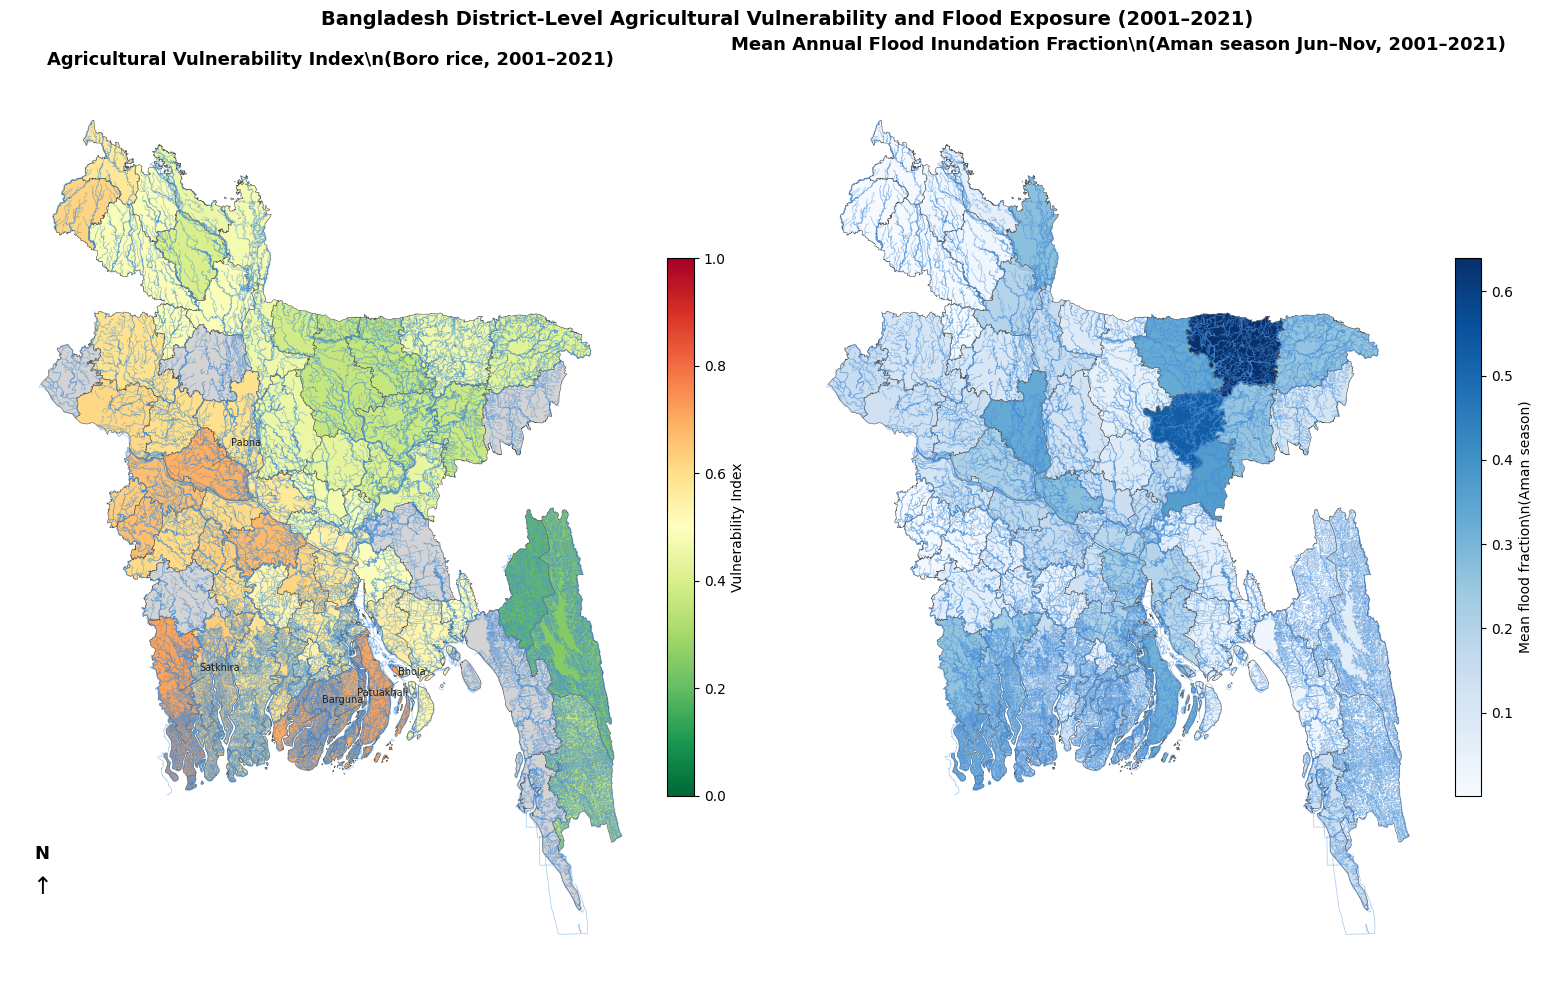

Publication figure saved → outputs\maps\fig1_vulnerability_flood_combined.png


In [12]:
gdf_plot    = gdf_master.to_crs("EPSG:3106")
rivers_proj = gdf_rivers.to_crs("EPSG:3106") if gdf_rivers is not None else None

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor("white")

# ── Left panel: Vulnerability Index ───────────────────────────────────────
ax1 = axes[0]
gdf_plot.plot(
    column      = "vulnerability_index",
    cmap        = "RdYlGn_r",
    linewidth   = 0.4,
    edgecolor   = "#555",
    legend      = True,
    legend_kwds = {"label": "Vulnerability Index", "shrink": 0.6, "pad": 0.02},
    missing_kwds= {"color": "lightgrey", "label": "No data"},
    vmin=0, vmax=1,
    ax          = ax1,
)
if rivers_proj is not None:
    rivers_proj.plot(ax=ax1, color="#4A90D9", linewidth=0.5, alpha=0.5)
ax1.set_title("Agricultural Vulnerability Index\\n(Boro rice, 2001–2021)",
              fontsize=13, fontweight="bold", pad=10)
ax1.axis("off")

# Annotate the 5 most vulnerable districts
for _, row in gdf_plot.nlargest(5, "vulnerability_index").iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax1.annotate(
        row["district_name"],
        xy=(cx, cy), xytext=(cx + 18000, cy + 18000),
        fontsize=7, color="#222",
        arrowprops={"arrowstyle": "-", "color": "#666", "lw": 0.5},
    )

ax1.annotate("N",  xy=(0.05, 0.13), xycoords="axes fraction",
             fontsize=13, ha="center", fontweight="bold")
ax1.annotate("↑",  xy=(0.05, 0.09), xycoords="axes fraction",
             fontsize=17, ha="center")

# ── Right panel: Mean Flood Fraction ──────────────────────────────────────
ax2 = axes[1]
gdf_plot.plot(
    column      = "mean_flood_fraction",
    cmap        = "Blues",
    linewidth   = 0.4,
    edgecolor   = "#555",
    legend      = True,
    legend_kwds = {"label": "Mean flood fraction\\n(Aman season)", "shrink": 0.6, "pad": 0.02},
    missing_kwds= {"color": "lightgrey", "label": "No data"},
    ax          = ax2,
)
if rivers_proj is not None:
    rivers_proj.plot(ax=ax2, color="#4A90D9", linewidth=0.5, alpha=0.5)
ax2.set_title("Mean Annual Flood Inundation Fraction\\n(Aman season Jun–Nov, 2001–2021)",
              fontsize=13, fontweight="bold", pad=10)
ax2.axis("off")

plt.suptitle(
    "Bangladesh District-Level Agricultural Vulnerability and Flood Exposure (2001–2021)",
    fontsize=14, fontweight="bold", y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

fig_path = MAPS / "fig1_vulnerability_flood_combined.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Publication figure saved → {fig_path}")

---
## Section 6. Gold Layer Extension — `fact_district_season_v2`

The flood variables extracted in this notebook are incorporated into the DuckDB Gold layer by creating an extended version of the fact table. `fact_district_season_v2` adds four columns to `fact_district_season`:

| Column | Type | Description |
|---|---|---|
| `flood_fraction` | float | JRC annual flood fraction for the Aman season (year-varying) |
| `flood_anomaly` | float | Z-score deviation from district long-run flood mean |
| `is_major_flood_year` | integer | Binary flag (1 = flood anomaly > 1.5 σ) |
| `flood_risk_category` | integer | BARC FLOODCAT code (time-invariant per district) |
| `flood_risk_tier` | string | Simplified three-tier classification (Low / Medium / High) |

This table is the primary input for all regression models in the statistical modelling notebook.

In [13]:
con.execute(f"""
CREATE OR REPLACE VIEW stg_flood AS
SELECT
    district_name,
    year,
    ROUND(flood_fraction,      4) AS flood_fraction,
    ROUND(flood_anomaly,       3) AS flood_anomaly,
    is_major_flood_year::INTEGER  AS is_major_flood_year
FROM read_parquet('{SILVER}/silver_flood_fraction.parquet')
WHERE district_name IS NOT NULL
""")

con.execute(f"""
CREATE OR REPLACE VIEW stg_flood_risk AS
SELECT
    district_name,
    flood_risk_category::INTEGER AS flood_risk_category,
    flood_risk_label,
    flood_risk_tier
FROM read_parquet('{SILVER}/silver_district_flood_risk.parquet')
WHERE district_name IS NOT NULL
""")

con.execute("""
CREATE OR REPLACE TABLE fact_district_season_v2 AS
SELECT
    f.*,
    fl.flood_fraction,
    fl.flood_anomaly,
    fl.is_major_flood_year,
    fr.flood_risk_category,
    fr.flood_risk_tier
FROM fact_district_season f
LEFT JOIN stg_flood      fl ON f.district_name = fl.district_name
                            AND f.year          = fl.year
LEFT JOIN stg_flood_risk fr ON f.district_name = fr.district_name
""")

print("fact_district_season_v2 created")
print()
print(q("""
SELECT
    season,
    COUNT(*)                         AS total_rows,
    COUNT(flood_fraction)            AS rows_with_flood,
    COUNT(flood_risk_tier)           AS rows_with_risk_tier,
    ROUND(AVG(flood_fraction)*100,2) AS avg_flood_pct
FROM fact_district_season_v2
GROUP BY season ORDER BY season
""").to_string(index=False))

fact_district_season_v2 created

season  total_rows  rows_with_flood  rows_with_risk_tier  avg_flood_pct
  aman        1472             1197                 1311          14.79
   aus        1472             1197                 1311          14.79
  boro        1472             1197                 1311          14.79


---
## Summary

### Key Spatial Finding

Global Moran's I = **0.804** (z = 8.31, p = 0.001) on the composite vulnerability index across 57 districts with valid spatial neighbours. This is a strong result indicating that agricultural vulnerability is geographically concentrated rather than randomly distributed.

LISA analysis identified 24 significant clusters at p < 0.05:
- **14 HH hotspot districts** — concentrated in Khulna and Barisal divisions, the southwest delta zone where river flooding and coastal tidal inundation converge
- **10 LL coldspot districts** — concentrated in Mymensingh, Sylhet, and the Chattogram hill tracts, where haor floodplain soils, proximity to national agricultural research institutions (BRRI, BARI), and lower coastal exposure create structural resilience

This spatial structure motivates the vulnerability-tier stratified subgroup analysis in the statistical modelling notebook, which shows that High-tier districts exhibit substantially larger negative flood coefficients than the national average.

In [14]:
print("=" * 55)
print("Phase 4 complete")
print("=" * 55)

print("\n── Silver files ──")
for fname in [
    "silver_flood_fraction.parquet",
    "silver_district_flood_risk.parquet",
    "silver_spatial_analysis.parquet",
]:
    p = SILVER / fname
    status = f"✓ ({p.stat().st_size//1024} KB)" if p.exists() else "✗ MISSING"
    print(f"  {status}  {fname}")

print("\n── Map outputs ──")
for f in sorted(MAPS.glob("*")):
    print(f"  ✓ {f.name}")

print("\n── Global Moran's I ──")
print(pd.read_csv(GIS / "global_morans_i_result.csv").to_string(index=False))

print("\n── LISA cluster counts ──")
gdf_lisa = gpd.read_parquet(SILVER / "silver_spatial_analysis.parquet")
print(gdf_lisa[gdf_lisa["lisa_sig"] == 1]["lisa_label"].value_counts().to_string())

print("\n── Gold layer coverage ──")
print(q("""
SELECT
    flood_risk_tier,
    COUNT(DISTINCT district_name)    AS districts,
    ROUND(AVG(flood_fraction)*100,1) AS avg_flood_pct,
    ROUND(AVG(boro_yield_mt_ha), 2)  AS avg_boro_yield
FROM fact_district_season_v2
WHERE season = 'boro' AND flood_risk_tier IS NOT NULL
GROUP BY flood_risk_tier ORDER BY avg_boro_yield
""").to_string(index=False))

con.close()
print("\nPhase 4 done. Ready for Phase 5 — Statistical Modelling.")

Phase 4 complete

── Silver files ──
  ✓ (29 KB)  silver_flood_fraction.parquet
  ✓ (4 KB)  silver_district_flood_risk.parquet
  ✓ (13709 KB)  silver_spatial_analysis.parquet

── Map outputs ──
  ✓ .ipynb_checkpoints
  ✓ fig1_vulnerability_flood_combined.png
  ✓ map1_vulnerability_index.html
  ✓ map2_flood_fraction.html
  ✓ map3_lisa_clusters.html

── Global Moran's I ──
 moran_i  expected_i  p_value  z_score  n_units  significant
  0.8041     -0.0179    0.001   8.1482       57         True

── LISA cluster counts ──
lisa_label
HH (hotspot)     15
LL (coldspot)    10

── Gold layer coverage ──
flood_risk_tier  districts  avg_flood_pct  avg_boro_yield
         Medium         20           18.3            3.81
            Low         23           12.2            4.04
           High         14           14.0            4.05

Phase 4 done. Ready for Phase 5 — Statistical Modelling.
